# Delay vs Epicentral Distance From Excel

Standalone notebook that reads the Excel result sheet, selects events using the available bands present for each event, and exports the target-style 2-panel figure.


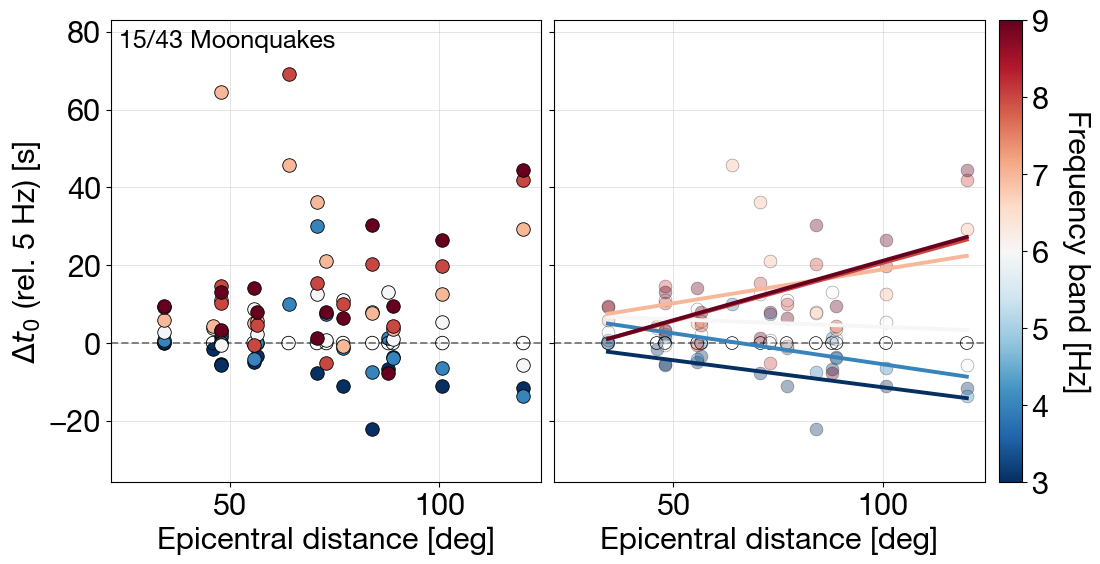

Kept events: 15/43
All rows plotted: 96
Rows used for fits: 93
Saved: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Plots_Single/Delay_vs_Epidist_fits_tol0.75_post2_kneg1_prepos1.pdf


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CONFIG
# Edit only SCENARIO to switch selection logic.
# ---------------------------------------------------------
XLSX = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
SHEET = "best_7_bands_fixed_hold0"
SAVE_DIR = "/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Plots_Single"
os.makedirs(SAVE_DIR, exist_ok=True)

FC = 5.0
BANDS = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
SIGMA_THRESHOLD = 3.0
SCENARIO = dict(name="tol0.75_post2_kneg1_prepos1", LOWER_TOL=0.75, MIN_POST=2, K_NEG=1, K_PRE_POS=1)

plt.rcParams.update({
    "font.family": "Helvetica Neue",
    "font.size": 22,
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})


def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(f"Missing columns in sheet '{sheet}': {missing}")

    d["station"] = d["station"].astype(str)
    d["fc_hz"] = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)
    d["starttime_dt"] = pd.to_datetime(d["starttime"], errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()
    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[["event", "station", "starttime_dt", "fc_hz", "dt_rel", "distance_deg", "t0_dt_mean_dt"]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


def sigma_filter_per_band(df_plot, *, ref_band, sigma_threshold):
    keep = np.ones(len(df_plot), dtype=bool)
    for band, g in df_plot.groupby("band"):
        if band == ref_band:
            continue
        vals = g["dt_rel"].to_numpy()
        std = np.std(vals, ddof=0)
        if std == 0:
            continue
        keep[g.index] = np.abs(vals - np.median(vals)) <= sigma_threshold * std
    return df_plot[keep].copy()


def plot_delay_vs_distance(plot_df, fit_df, *, scenario_name, ref_band, bands, save_dir, n_kept, n_total):
    cmap = plt.get_cmap("RdBu_r")
    norm = plt.Normalize(bands.min(), bands.max())

    dt_all = plot_df["dt_rel"].to_numpy()
    ymin = np.nanmin(dt_all)
    ymax = np.nanmax(dt_all)
    span = ymax - ymin if ymax > ymin else 1.0
    ymin -= 0.15 * span
    ymax += 0.15 * span

    xmin = plot_df["distance"].min()
    xmax = plot_df["distance"].max()
    dx = xmax - xmin if xmax > xmin else 1.0
    xmin -= 0.15 * dx
    xmax += 0.05 * dx

    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(12, 6), sharey=True,
        gridspec_kw={"wspace": 0.03}
    )

    for ax in (ax_left, ax_right):
        ax.axhline(0, color="0.5", linestyle="--", linewidth=1.4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, alpha=0.35, linewidth=0.7)

    for band in bands:
        g_all = plot_df[plot_df["band"] == band]
        if g_all.empty:
            continue
        color = cmap(norm(band))
        is_ref = np.isclose(band, ref_band)

        ax_left.scatter(
            g_all["distance"],
            g_all["dt_rel"],
            s=95,
            facecolors="none" if is_ref else color,
            edgecolors="k",
            linewidths=0.6,
            alpha=1.0,
            zorder=3,
        )

        g_fit = fit_df[fit_df["band"] == band]
        if g_fit.empty:
            continue

        ax_right.scatter(
            g_fit["distance"],
            g_fit["dt_rel"],
            s=85,
            facecolors="none" if is_ref else color,
            edgecolors="k",
            linewidths=0.5,
            alpha=0.35 if not is_ref else 1.0,
            zorder=2,
        )

        if is_ref or len(g_fit) < 2:
            continue

        x = g_fit["distance"].to_numpy()
        y = g_fit["dt_rel"].to_numpy()
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        yy = slope * xx + intercept
        ax_right.plot(xx, yy, color=color, linewidth=2.8, zorder=4)

    ax_left.set_xlabel("Epicentral distance [deg]")
    ax_left.set_ylabel(r"$\Delta t_0$ (rel. 5 Hz) [s]")
    ax_right.set_xlabel("Epicentral distance [deg]")

    ax_left.text(
        0.02, 0.98, f"{n_kept}/{n_total} Moonquakes",
        transform=ax_left.transAxes,
        ha="left", va="top", fontsize=18,
    )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_left, ax_right], fraction=0.045, pad=0.015)
    cbar.set_label("Frequency band [Hz]", rotation=270, labelpad=30)

    out_path = os.path.join(save_dir, f"Delay_vs_Epidist_fits_{scenario_name}.pdf")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return out_path


df_long = load_excel_long(XLSX, SHEET, FC=FC, BANDS=BANDS)
dt_mat = build_event_band_matrix(df_long, BANDS=BANDS)
keep_mask = select_events(
    dt_mat=dt_mat,
    FC=FC,
    BANDS=BANDS,
    MIN_POST=int(SCENARIO["MIN_POST"]),
    K_NEG=int(SCENARIO["K_NEG"]),
    K_PRE_POS=int(SCENARIO["K_PRE_POS"]),
    LOWER_TOL=float(SCENARIO["LOWER_TOL"]),
)

kept_events = keep_mask.index[keep_mask].tolist()
plot_df = (
    df_long[df_long["event"].isin(kept_events)]
    .dropna(subset=["distance_deg", "dt_rel"])
    .rename(columns={"distance_deg": "distance"})
    .sort_values(["event", "band"])
    .reset_index(drop=True)
)
if plot_df.empty:
    raise RuntimeError("No rows left after Excel-based scenario filtering.")

fit_df = sigma_filter_per_band(plot_df, ref_band=FC, sigma_threshold=SIGMA_THRESHOLD)
out_path = plot_delay_vs_distance(
    plot_df,
    fit_df,
    scenario_name=SCENARIO["name"],
    ref_band=FC,
    bands=BANDS,
    save_dir=SAVE_DIR,
    n_kept=len(kept_events),
    n_total=len(dt_mat),
)

print(f"Kept events: {len(kept_events)}/{len(dt_mat)}")
print(f"All rows plotted: {len(plot_df)}")
print(f"Rows used for fits: {len(fit_df)}")
print(f"Saved: {out_path}")


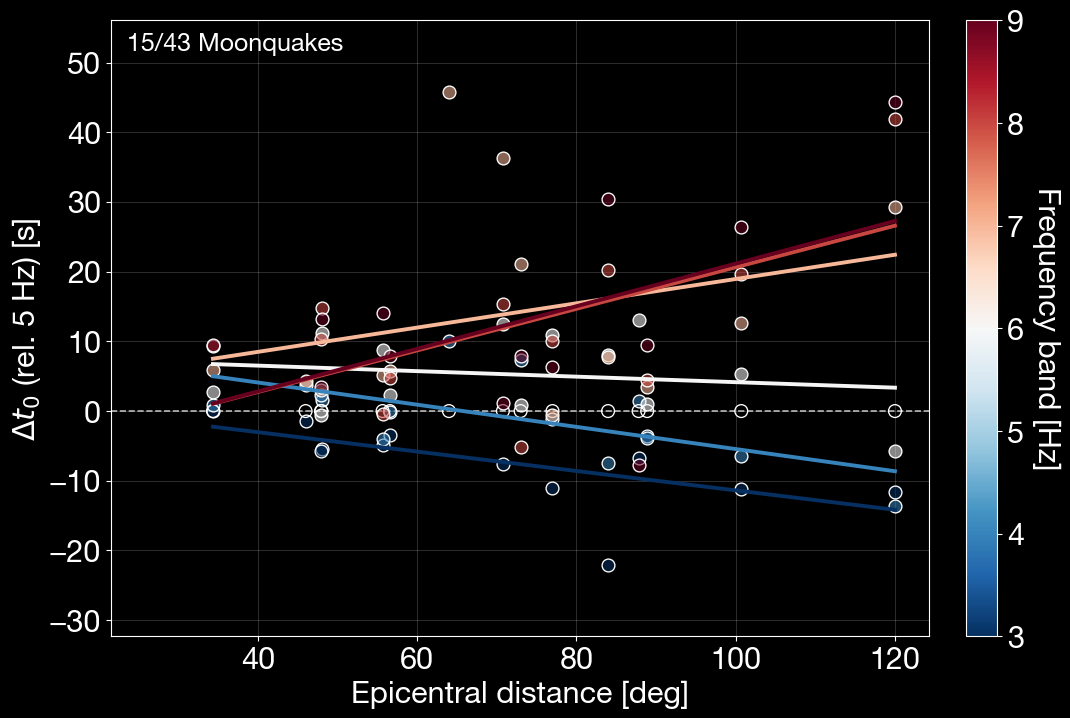

Saved: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Plots_Single/Delay_vs_Epidist_fits_tol0.75_post2_kneg1_prepos1_right_inverted.pdf


In [2]:
# Right-panel-only version with simple inverted styling.
# Run the previous cell first.

required = ["fit_df", "SCENARIO", "FC", "BANDS", "SAVE_DIR", "kept_events", "dt_mat"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Run the previous cell first. Missing: {missing}")

BG_COLOR = "black"
FG_COLOR = "white"
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(BANDS.min(), BANDS.max())

dt_all = fit_df["dt_rel"].to_numpy()
ymin = np.nanmin(dt_all)
ymax = np.nanmax(dt_all)
span = ymax - ymin if ymax > ymin else 1.0
ymin -= 0.15 * span
ymax += 0.15 * span

xmin = fit_df["distance"].min()
xmax = fit_df["distance"].max()
dx = xmax - xmin if xmax > xmin else 1.0
xmin -= 0.15 * dx
xmax += 0.05 * dx

fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.axhline(0, color=FG_COLOR, linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid(True, alpha=0.18, linewidth=0.7, color=FG_COLOR)

for spine in ax.spines.values():
    spine.set_color(FG_COLOR)

ax.tick_params(colors=FG_COLOR, which="both")
ax.xaxis.label.set_color(FG_COLOR)
ax.yaxis.label.set_color(FG_COLOR)
ax.title.set_color(FG_COLOR)

for band in BANDS:
    g_fit = fit_df[fit_df["band"] == band]
    if g_fit.empty:
        continue

    color = cmap(norm(band))
    is_ref = np.isclose(band, FC)

    marker_face = "none" if is_ref else plt.matplotlib.colors.to_rgba(color, alpha=0.55)

    ax.scatter(
        g_fit["distance"],
        g_fit["dt_rel"],
        s=85,
        facecolors=marker_face,
        edgecolors=FG_COLOR,
        linewidths=0.95,
        zorder=2,
    )

    if is_ref or len(g_fit) < 2:
        continue

    x = g_fit["distance"].to_numpy()
    y = g_fit["dt_rel"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    yy = slope * xx + intercept
    ax.plot(xx, yy, color=color, linewidth=2.8, zorder=4)

ax.text(
    0.02, 0.98, f"{len(kept_events)}/{len(dt_mat)} Moonquakes",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=18, color=FG_COLOR,
)

# ax.set_title("Relative delays with per-band fits")
ax.set_xlabel("Epicentral distance [deg]")
ax.set_ylabel(r"$\Delta t_0$ (rel. 5 Hz) [s]")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.08, pad=0.04)
cbar.set_label("Frequency band [Hz]", rotation=270, labelpad=26, color=FG_COLOR)
cbar.ax.yaxis.set_tick_params(color=FG_COLOR)
plt.setp(cbar.ax.get_yticklabels(), color=FG_COLOR)
cbar.outline.set_edgecolor(FG_COLOR)
cbar.ax.set_facecolor(BG_COLOR)

out_path_inverted = os.path.join(
    SAVE_DIR,
    f"Delay_vs_Epidist_fits_{SCENARIO['name']}_right_inverted.pdf",
)
fig.savefig(out_path_inverted, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

print(f"Saved: {out_path_inverted}")


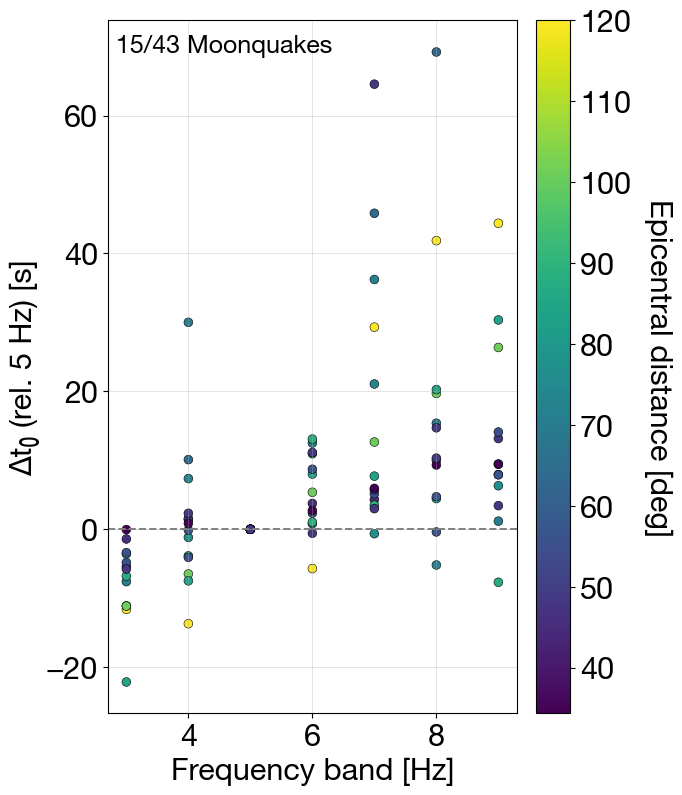

Saved: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Plots_Single/Delay_vs_band_tol0.75_post2_kneg1_prepos1.pdf


In [3]:
# Delay vs band for the same Excel-selected events.
# Run the first cell first.

required = ["plot_df", "SCENARIO", "FC", "SAVE_DIR", "kept_events", "dt_mat"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Run the first cell first. Missing: {missing}")

OUT_PATH_BAND = os.path.join(
    SAVE_DIR,
    f"Delay_vs_band_{SCENARIO['name']}.pdf",
)

fig, ax = plt.subplots(figsize=(6, 9))
cmap_dist = plt.get_cmap("viridis")

mappable_for_cbar = None
if not plot_df.empty:
    norm_dist = plt.Normalize(plot_df["distance"].min(), plot_df["distance"].max())
    sc = ax.scatter(
        plot_df["band"],
        plot_df["dt_rel"],
        c=plot_df["distance"],
        cmap=cmap_dist,
        norm=norm_dist,
        s=40,
        edgecolor="k",
        linewidths=0.4,
    )
    mappable_for_cbar = sc

ax.axhline(0, color="0.5", linestyle="--", linewidth=1.4)
ax.grid(True, alpha=0.35, linewidth=0.7)
ax.set_xlabel("Frequency band [Hz]")
ax.set_ylabel(f"Δt₀ (rel. {FC:g} Hz) [s]")


ax.text(
    0.02, 0.98, f"{len(kept_events)}/{len(dt_mat)} Moonquakes",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=18,
)

if mappable_for_cbar is not None:
    cbar = fig.colorbar(mappable_for_cbar, ax=ax, fraction=0.08, pad=0.04)
    cbar.set_label("Epicentral distance [deg]", rotation=270, labelpad=30)

fig.savefig(OUT_PATH_BAND, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {OUT_PATH_BAND}")


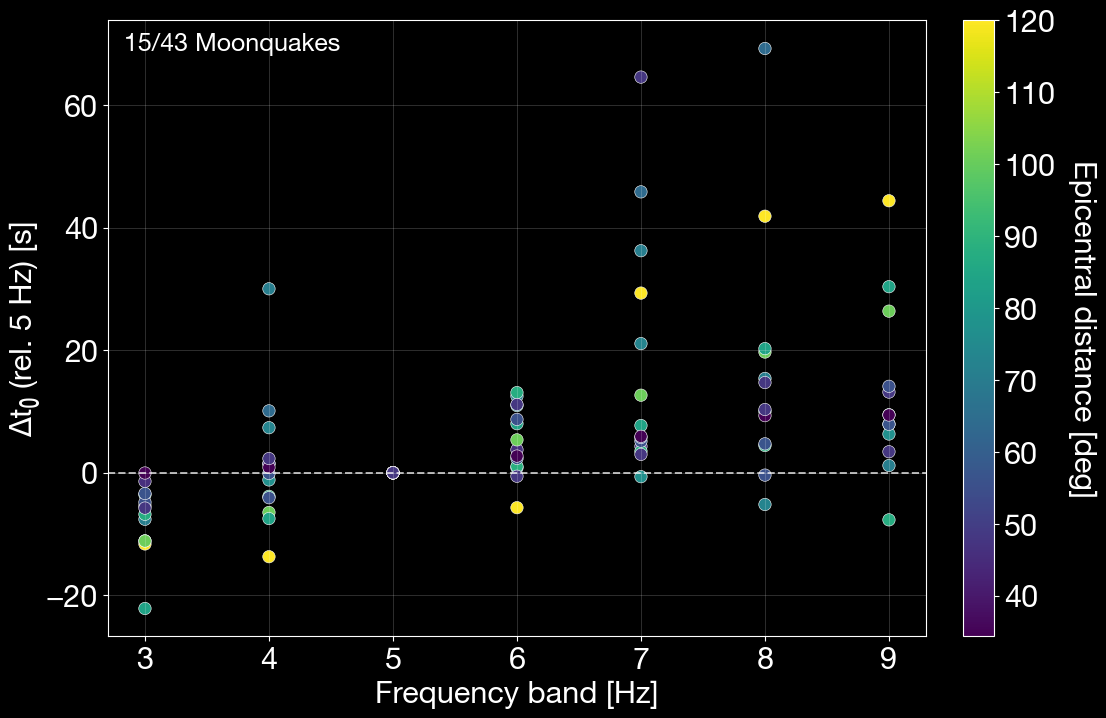

Saved: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Plots_Single/Delay_vs_band_tol0.75_post2_kneg1_prepos1_inverted.pdf


In [4]:
# Inverted-style Delay vs band plot.
# Keeps the same distance colormap as the previous cell.
# Run the first cell first.

required = ["plot_df", "SCENARIO", "FC", "SAVE_DIR", "kept_events", "dt_mat"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Run the first cell first. Missing: {missing}")

OUT_PATH_BAND_INVERTED = os.path.join(
    SAVE_DIR,
    f"Delay_vs_band_{SCENARIO['name']}_inverted.pdf",
)

BG_COLOR = "black"
FG_COLOR = "white"

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)
cmap_dist = plt.get_cmap("viridis")

mappable_for_cbar = None
if not plot_df.empty:
    norm_dist = plt.Normalize(plot_df["distance"].min(), plot_df["distance"].max())
    sc = ax.scatter(
        plot_df["band"],
        plot_df["dt_rel"],
        c=plot_df["distance"],
        cmap=cmap_dist,
        norm=norm_dist,
        s=80,
        edgecolor=FG_COLOR,
        linewidths=0.4,
    )
    mappable_for_cbar = sc

ax.axhline(0, color=FG_COLOR, linestyle="--", linewidth=1.4, alpha=0.7)
ax.grid(True, alpha=0.18, linewidth=0.7, color=FG_COLOR)
ax.set_xlabel("Frequency band [Hz]", color=FG_COLOR)
ax.set_ylabel(f"Δt₀ (rel. {FC:g} Hz) [s]", color=FG_COLOR)


ax.text(
    0.02, 0.98, f"{len(kept_events)}/{len(dt_mat)} Moonquakes",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=18, color=FG_COLOR,
)

for spine in ax.spines.values():
    spine.set_color(FG_COLOR)
ax.tick_params(colors=FG_COLOR, which="both")

if mappable_for_cbar is not None:
    cbar = fig.colorbar(mappable_for_cbar, ax=ax, fraction=0.08, pad=0.04)
    cbar.set_label("Epicentral distance [deg]", rotation=270, labelpad=30, color=FG_COLOR)
    cbar.ax.yaxis.set_tick_params(color=FG_COLOR)
    plt.setp(cbar.ax.get_yticklabels(), color=FG_COLOR)
    cbar.outline.set_edgecolor(FG_COLOR)
    cbar.ax.set_facecolor(BG_COLOR)

fig.savefig(OUT_PATH_BAND_INVERTED, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

print(f"Saved: {OUT_PATH_BAND_INVERTED}")


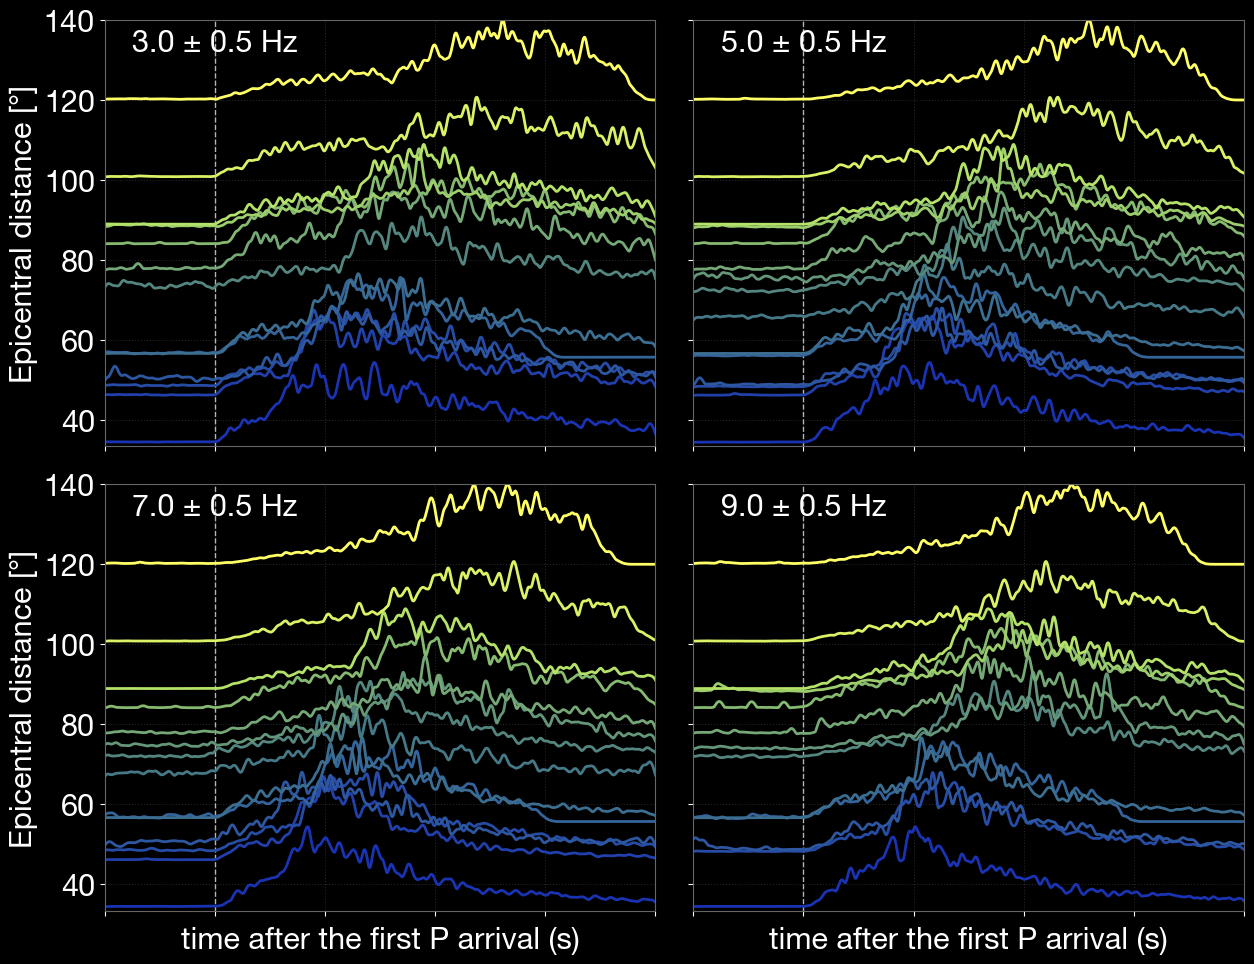

Kept events after MiniSEED matching: 15/43
Saved: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Plots_Single/Envelope_distance_inverted_3_5_7_9Hz_win20_LOWER_TOL=0.75_MIN_POST=2_K_NEG=1_K_PRE_POS=1.pdf


In [11]:
# Inverted envelope-distance plot for 3, 5, 8, and 9 Hz.
# Rebuilds: Envelope_distance_inverted_3_5_8_9Hz_win20_LOWER_TOL=0.75_MIN_POST=2_K_NEG=1_K_PRE_POS=1.pdf
# Run after the first cell so SCENARIO, load_excel_long, build_event_band_matrix, and select_events exist.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window
from cmcrameri import cm as cmc

required = ["XLSX", "SHEET", "SAVE_DIR", "FC", "SCENARIO", "load_excel_long", "build_event_band_matrix", "select_events"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Run the first cell first. Missing: {missing}")

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"
STARTTIME_TOL_S = 2.0
CENTERS = np.array([3.0, 5.0, 7.0, 9.0])
ALL_BANDS = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
HALF_BW = 0.5
BP_ORDER = 4
WIN_S = 20
T_BEFORE = 200
T_AFTER = 800
AMP_SCALE_DEG = 20
BG_COLOR = "black"
FG_COLOR = "white"
OUT_PATH = os.path.join(
    SAVE_DIR,
    f"Envelope_distance_inverted_3_5_7_9Hz_win{WIN_S:02d}_LOWER_TOL={float(SCENARIO['LOWER_TOL']):g}_MIN_POST={int(SCENARIO['MIN_POST'])}_K_NEG={int(SCENARIO['K_NEG'])}_K_PRE_POS={int(SCENARIO['K_PRE_POS'])}.pdf",
)

plt.rcParams.update({
    "font.family": "Helvetica Neue",
    "font.size": 22,
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})


def band_edges(fc, half_bw, fs):
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu


def env_and_rms(x, fs, fl, fu, win_s, order):
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    nwin = int(round(win_s * fs)) | 1
    w = get_window("hann", nwin)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env ** 2, w, mode="same"))
    return env, rms


def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")
        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]
            prev = event_to_trace.get(ev)
            if prev is None or dt.loc[j] < prev[1]:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


scenario_bands = ALL_BANDS.copy()
df_env = load_excel_long(XLSX, SHEET, FC=FC, BANDS=scenario_bands)
dt_mat_env = build_event_band_matrix(df_env, BANDS=scenario_bands)
keep_mask_env = select_events(
    dt_mat=dt_mat_env,
    FC=FC,
    BANDS=scenario_bands,
    MIN_POST=int(SCENARIO["MIN_POST"]),
    K_NEG=int(SCENARIO["K_NEG"]),
    K_PRE_POS=int(SCENARIO["K_PRE_POS"]),
    LOWER_TOL=float(SCENARIO["LOWER_TOL"]),
)

kept_events_env = keep_mask_env.index[keep_mask_env].tolist()
t0_lookup = (
    df_env[["event", "band", "t0_dt_mean_dt"]]
    .drop_duplicates(subset=["event", "band"])
    .set_index(["event", "band"])["t0_dt_mean_dt"]
)
dist_map = (
    df_env[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_env, tol_s=STARTTIME_TOL_S)
kept_events_env = [ev for ev in kept_events_env if ev in event_to_trace]

ev_dist = [(ev, float(dist_map.get(ev, np.nan))) for ev in kept_events_env]
ev_dist = [(ev, dist) for ev, dist in ev_dist if np.isfinite(dist)]
ev_dist.sort(key=lambda pair: pair[1])
if not ev_dist:
    raise RuntimeError("No finite distances among kept events after MiniSEED matching.")

dist_min = ev_dist[0][1]
dist_max = ev_dist[-1][1]
frac = np.array([0.5]) if len(ev_dist) == 1 else np.linspace(0.0, 1.0, len(ev_dist))
event_color = {ev: cmc.imola(f) for (ev, _), f in zip(ev_dist, frac)}

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True, facecolor=BG_COLOR)
axes = axes.flatten()

for ax in axes:
    ax.set_facecolor(BG_COLOR)
    ax.grid(True, ls=":", alpha=0.15, color=FG_COLOR)
    ax.axvline(0, color=FG_COLOR, ls="--", lw=1.0, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_color("0.4")
    ax.tick_params(colors=FG_COLOR, which="both")
    ax.xaxis.label.set_color(FG_COLOR)
    ax.yaxis.label.set_color(FG_COLOR)
    ax.title.set_color(FG_COLOR)

for i, fc in enumerate(CENTERS):
    ax = axes[i]

    for ev, dist in ev_dist:
        key = (ev, float(fc))
        if key not in t0_lookup.index:
            continue

        t0_dt = t0_lookup.loc[key]
        if pd.isna(t0_dt):
            continue

        tr = event_to_trace[ev]
        t0 = UTCDateTime(pd.Timestamp(t0_dt).to_pydatetime())
        t1, t2 = t0 - T_BEFORE, t0 + T_AFTER

        trc = tr.copy()
        try:
            trc.trim(t1, t2, pad=True, fill_value=0.0)
        except Exception:
            continue

        fs = float(trc.stats.sampling_rate)
        u = trc.data.astype(float)
        if u.size < 10:
            continue

        t_rel = np.arange(len(u)) / fs - T_BEFORE
        fl, fu = band_edges(fc, HALF_BW, fs)
        _, rms = env_and_rms(u, fs, fl, fu, WIN_S, BP_ORDER)

        max_rms = np.nanmax(rms)
        if not np.isfinite(max_rms) or max_rms <= 0:
            continue

        y = dist + AMP_SCALE_DEG * (rms / max_rms)
        ax.plot(t_rel, y, lw=2, color=event_color[ev], alpha=1.0)

    ax.text(0.05, 0.98, f"{fc:.1f} ± {HALF_BW} Hz", ha="left", va="top", transform=ax.transAxes, color=FG_COLOR)
    ax.set_xlim(-T_BEFORE, T_AFTER)
    ax.set_ylim(dist_min - 1.0, dist_max + 20)

for ax in axes[:2]:
    ax.set_xticklabels([])
for ax in axes[2:]:
    ax.set_xlabel("time after the first P arrival (s)")
for ax in (axes[0], axes[2]):
    ax.set_ylabel("Epicentral distance [°]")

fig.tight_layout()
fig.savefig(OUT_PATH, dpi=200, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

print(f"Kept events after MiniSEED matching: {len(ev_dist)}/{len(dt_mat_env)}")
print(f"Saved: {OUT_PATH}")
